In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import itertools
import numpy as np
import pandas as pd
import joblib
import os
import re
from pathlib import Path
import sys
from sklearn.metrics import v_measure_score
from sklearn.metrics import adjusted_rand_score

sys.path.append(str(Path.cwd().parent))

from utils.analysis import *
import utils.plotting as plotting

In [2]:
PROJECT_ROOT = Path(
    "/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project"
)

OUTPUT_DIR = PROJECT_ROOT / 'outputs/Ear/Pavel/Results/'
DROPOUT_PREFIX = "dropout_observed_counts_"
TRUE_EXPR_PREFIX = "real_true_gene_expr_"
H5AD_ROOT = PROJECT_ROOT / "outputs/Ear/Pavel/Data/"
FIGURE_DIR = PROJECT_ROOT / "outputs/Ear/Pavel/Figures/"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATANAME = "Ear"
DROPOUT = "Pavel"
TARGET = "0.8748" # Target dropout rate for loss function analysis.

In [3]:
plotting.set_params()
paths = find_pickle_files(OUTPUT_DIR)
print(f"Found {len(paths)} pickle files in {OUTPUT_DIR}")

Found 420 pickle files in /dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/outputs/Ear/Pavel/Results


In [4]:
results = []

for i, file in enumerate(paths):
    # Load the object
    obj = joblib.load(file)

    # Extract parameters from filename
    base_info = extract_params(file)
    # Merge all attributes of the object into base_info
    full_info = extend_with_attributes(obj, base_info)

    # Remove large data to save memory
    del full_info["preprocessed"]
    del full_info["embeddings"]
    if "kmeans" in full_info:
        del full_info["kmeans"]
    # del full_info["umap"]
    del full_info["tsne"]
    results.append(full_info)

# Create DataFrame
df_results = pd.DataFrame(results)

# Check for NaN values
if df_results.isna().any().any():
    print("Warning: DataFrame contains NaN values.")

/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/dtu-compute/digitstem/zuzanna/zuzanna_dropout_project/.conda-env/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [5]:
# Group by seed to see number of entries per seed
df_results.groupby(["seed"]).count()

,method,genes,cells,dropout,factor,rate,datatype,dataname,additional,leiden,losses,parameters,timings,umap
seed,,,,,,,,,,,,,,
1,42,42,0,42,0,35,42,42,42,42,42,42,42,42
2,42,42,0,42,0,35,42,42,42,42,42,42,42,42
3,42,42,0,42,0,35,42,42,42,42,42,42,42,42
4,42,42,0,42,0,35,42,42,42,42,42,42,42,42
5,42,42,0,42,0,35,42,42,42,42,42,42,42,42
6,42,42,0,42,0,35,42,42,42,42,42,42,42,42
7,42,42,0,42,0,35,42,42,42,42,42,42,42,42
8,42,42,0,42,0,35,42,42,42,42,42,42,42,42
9,42,42,0,42,0,35,42,42,42,42,42,42,42,42


In [6]:
# Create a separate DataFrame for dropout results
dropout_results = df_results.copy()

# Clean up memory
del df_results

# Check unique dropout percentages
dropout_results.dropout.unique()


array([0.9388, 0.9817, 0.8962, 0.8748, 0.9177, 0.9603])

### Visualization

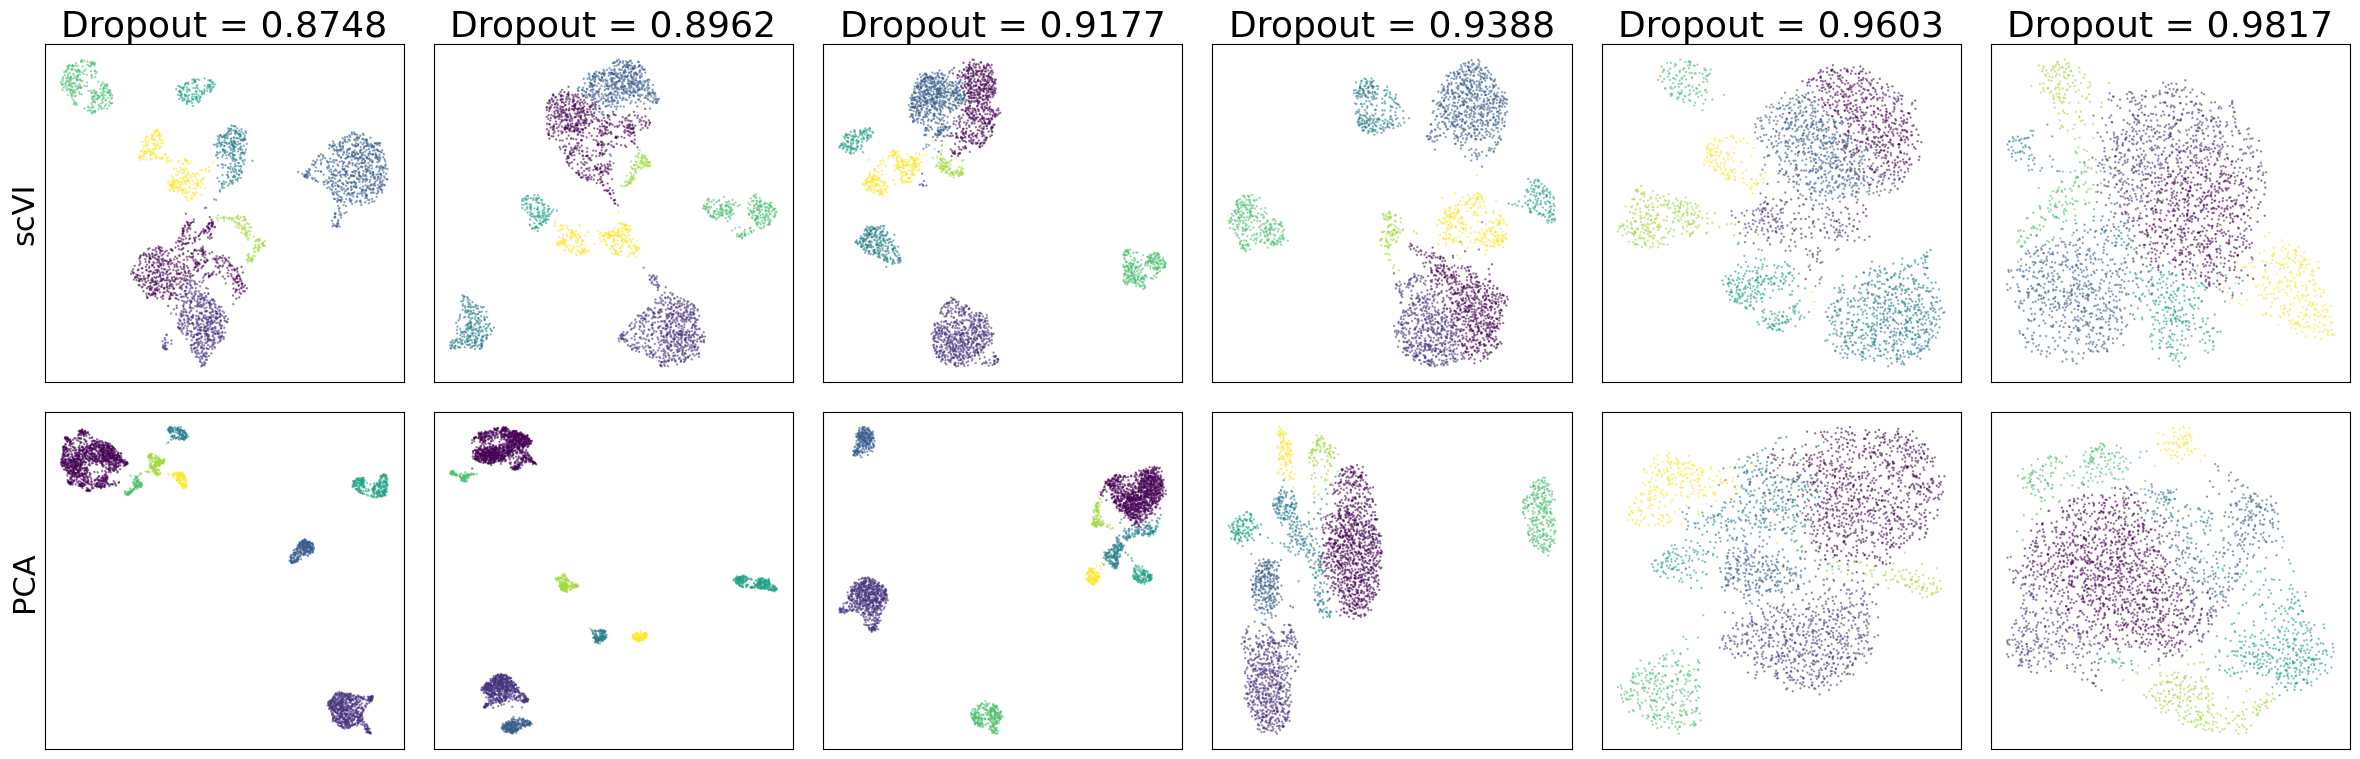

In [7]:
# parameters
seed = 3
n_latent = 20
n_components = 100

# extract necessary data
results = dropout_results[["method", "parameters", "dropout", "umap", "leiden", "seed"]].copy()
params_expanded = results["parameters"].apply(parse_params).apply(pd.Series)
results = pd.concat([results.drop(columns=["parameters"]), params_expanded], axis=1)

# dropout rates to be plotted (% of zeros)
dropout_rates = sorted(dropout_results["dropout"].unique())

# plotting
plotting.set_params()
ncols = len(dropout_rates)
fig, axes = plt.subplots(2, ncols, figsize=(4*ncols, 8))

# plot scvi umap
for i, d in enumerate(dropout_rates):
    scvi_results = results[(results["method"] == "scvi") & 
                           (results["n_latent"] == n_latent) & 
                           (results["dropout"] == d) & 
                           (results["seed"] == seed)]
    labels = scvi_results.leiden.values[0].values.astype(int)
    axes[0, i].set_title(f"Dropout = {d:.4f}")
    axes[0, i].scatter(scvi_results.umap.values[0][:, 0], scvi_results.umap.values[0][:, 1], c=labels, s=0.5, alpha=0.5)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

axes[0, 0].set_ylabel("scVI")

# plot pca umap
for i, d in enumerate(dropout_rates):
    pca_results = results[(results["method"] == "pca") & 
                          (results["n_components"] == n_components) & 
                          (results["dropout"] == d) & 
                          (results["seed"] == seed)]
    labels = pca_results.leiden.values[0].values.astype(int)
    # axes[1, i].set_title(f"Dropout = {d}")
    axes[1, i].scatter(pca_results.umap.values[0][:, 0], pca_results.umap.values[0][:, 1], c=labels, s=0.5, alpha=0.5)
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[1, 0].set_ylabel("PCA")

plt.tight_layout()

In [8]:
fig.savefig(FIGURE_DIR / "UMAP", dpi=300, bbox_inches="tight")

In [9]:
del results

### Cluster Accuracy

In [10]:
results = []

for file in paths:
    # Load the object
    obj = joblib.load(file)

    base_info = extract_params(file)
    full_info = extend_with_attributes(obj, base_info)

    # derive matching h5ad from pkl filename
    m = re.search(
        rf"({re.escape(DROPOUT_PREFIX)}.*?seed)",
        os.path.basename(file),
    )
    if not m:
        m = re.search(
            rf"({re.escape(TRUE_EXPR_PREFIX)}.*?seed)",
            os.path.basename(file),
        )
        if not m:
            print(f"No h5ad match for {file}")
            continue
    # path to h5ad
    h5ad_path = os.path.join(H5AD_ROOT, f"{m.group(1)}.h5ad")
    if not os.path.exists(h5ad_path):
        print(f"Missing h5ad: {h5ad_path}")
        continue

    # true labels from h5ad
    adata = sc.read_h5ad(h5ad_path)
    true_labels = adata.obs["group"].values
    dropout_labels = full_info["leiden"].values

    # Compute v-measure
    vm = v_measure_score(true_labels, dropout_labels)
    
    # Remove 'seed' key if it exists
    clean_params = {k: v for k, v in full_info["parameters"].items() if k != "seed"}

    # Convert to string for grouping
    params_str = str({k: str(v) for k, v in clean_params.items()})

    # Store result
    results.append(
        {
            "method": full_info["method"],
            "dropout": full_info["dropout"],
            "seed": full_info["seed"],
            "parameters": params_str,
            "vmeasure": vm,
        }
    )

# Build DataFrame
results_df = pd.DataFrame(results)

# Group by method, dropout, parameters (but not seed!)
summary = (
    results_df.groupby(["method", "dropout", "parameters"])["vmeasure"]
    .agg(
        median="median",
        q10=lambda s: s.quantile(0.10),
        q90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)
params_expanded = summary["parameters"].apply(parse_params).apply(pd.Series)
summary = pd.concat([summary.drop(columns=["parameters"]), params_expanded], axis=1)
summary["dropout"] = pd.to_numeric(summary["dropout"], errors="coerce")
summary.head()

,method,dropout,median,q10,q90,n_components,highly_variable_genes,normalize_total,log1p,scale,unique_groups,n_latent,n_hidden,n_layers,likelihood,n_epochs,batch_size,device
0,pca,0.8748,0.775665,0.728056,0.776362,10,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pca,0.8748,0.819390,0.780695,0.819390,100,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pca,0.8748,0.820503,0.819345,0.820503,400,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pca,0.8748,0.820723,0.815600,0.820723,50,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pca,0.8962,0.826108,0.782162,0.831020,10,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


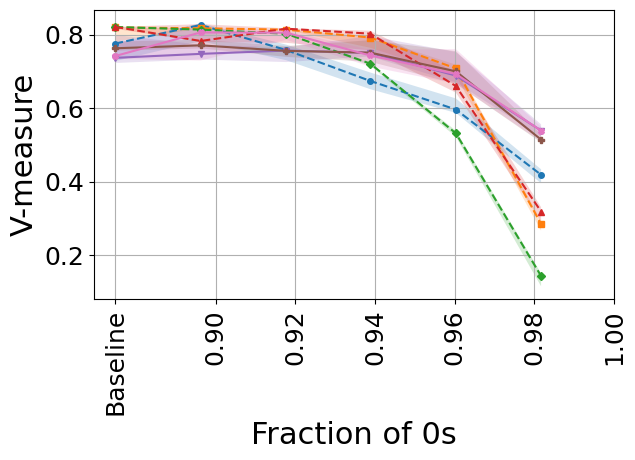

In [11]:
plotting.plot_summary(
    summary,
    measure="V-measure",
    save=FIGURE_DIR / f"vmeasure_{DATANAME}_{DROPOUT}.png",
)
plt.show()

In [12]:
del results_df
del summary

### Cluster Stability

In [13]:
records = []

for file in paths:
    obj = joblib.load(file)
    base_info = extract_params(file)
    full_info = extend_with_attributes(obj, base_info)

    basename = os.path.basename(file)

    if re.search(re.escape(DROPOUT_PREFIX), basename):
        full_info["source"] = "observed_counts"
    elif re.search(re.escape(TRUE_EXPR_PREFIX), basename):
        full_info["source"] = "true_gene_expr"
    else:
        print(f"Could not determine source for {file}")
        continue

    records.append(full_info)

stability_df = pd.DataFrame(records)

baseline = stability_df[stability_df["source"] == "true_gene_expr"].copy()
observed = stability_df[stability_df["source"] == "observed_counts"].copy()

results = []

for res in observed.itertuples():
    # Match baseline
    match = baseline[
        (baseline["method"] == res.method)
#        & (baseline["dataname"] == res.dataname)
        & (baseline["genes"] == res.genes)
        & (baseline["seed"] == res.seed)
        & (baseline["parameters"].apply(parse_params) == parse_params(res.parameters))
    ]

    if match.empty:
        print(
            f"No baseline match for method={res.method}, seed={res.seed}, "
            f"dataname={res.dataname}, genes={res.genes}, parameters={res.parameters}"
        )
        continue

    if len(match) > 1:
        print(
            f"Multiple baseline matches for method={res.method}, seed={res.seed}, "
            f"dataname={res.dataname}, genes={res.genes}, parameters={res.parameters}; using first"
        )

    try:
        baseline_labels = match.iloc[0]["leiden"].values
        dropout_labels = res.leiden.values

        ari = adjusted_rand_score(baseline_labels, dropout_labels)

        clean_params = {
            k: v for k, v in parse_params(res.parameters).items()
            if k != "seed"
        }
        params_str = str({k: str(v) for k, v in clean_params.items()})

        results.append(
            {
                "method": res.method,
                "dropout": res.dropout,
                "seed": res.seed,
                "parameters": params_str,
                "ari": ari,
            }
        )

    except Exception as e:
        print(f"Error comparing method={res.method}, seed={res.seed}, dropout={res.dropout}: {e}")

# Add baseline self-comparisons: baseline vs baseline has ARI = 1
for res in baseline.itertuples():
    try:
        clean_params = {
            k: v for k, v in parse_params(res.parameters).items()
            if k != "seed"
        }
        params_str = str({k: str(v) for k, v in clean_params.items()})

        results.append(
            {
                "method": res.method,
                "dropout": res.dropout,
                "seed": res.seed,
                "parameters": params_str,
                "ari": 1.0,
            }
        )

    except Exception as e:
        print(
            f"Error adding baseline ARI for method={res.method}, "
            f"seed={res.seed}, dropout={res.dropout}: {e}"
        )
        
results_df = pd.DataFrame(results)

summary = (
    results_df.groupby(["method", "dropout", "parameters"])["ari"]
    .agg(
            median="median",
            q10=lambda s: s.quantile(0.10),
            q90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

params_expanded = summary["parameters"].apply(parse_params).apply(pd.Series)
summary = pd.concat([summary.drop(columns=["parameters"]), params_expanded], axis=1)
summary["dropout"] = pd.to_numeric(summary["dropout"], errors="coerce")
summary.head()


,method,dropout,median,q10,q90,n_components,highly_variable_genes,normalize_total,log1p,scale,unique_groups,n_latent,n_hidden,n_layers,likelihood,n_epochs,batch_size,device
0,pca,0.8748,1.00000,1.000000,1.00000,10,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pca,0.8748,1.00000,1.000000,1.00000,100,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pca,0.8748,1.00000,1.000000,1.00000,400,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pca,0.8748,1.00000,1.000000,1.00000,50,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pca,0.8962,0.82106,0.690373,0.91233,10,False,True,True,False,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


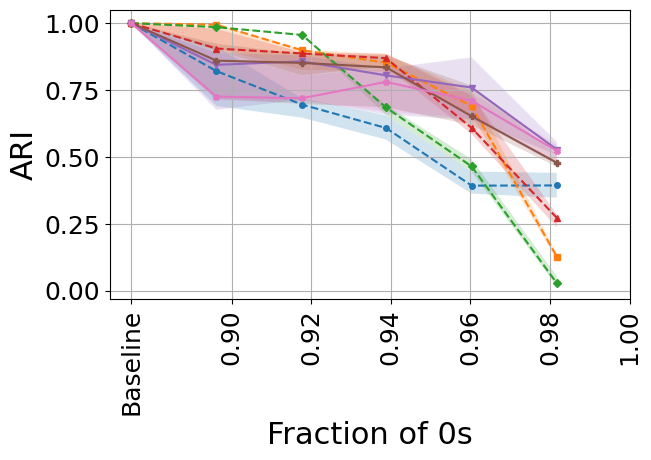

In [14]:
plotting.plot_summary(
    summary,
    measure="ARI",
    save=FIGURE_DIR / f"ARI_{DATANAME}_{DROPOUT}.png",
)
plt.show()

In [15]:
del results_df
del summary

### Runtimes

In [16]:
timings = dropout_results.timings.apply(parse_params).apply(pd.Series)
params = dropout_results.parameters.apply(parse_params).apply(pd.Series)
measured_dropout_rate = dropout_results.additional.apply(parse_params).apply(pd.Series)
df = pd.concat([dropout_results.drop(columns=['timings', 'parameters', 'leiden', 'additional', 'umap']), measured_dropout_rate, params, timings], axis=1)
df.head().astype(str)

,method,genes,cells,dropout,factor,rate,datatype,dataname,seed,losses,...,n_components,normalize_total,log1p,scale,preprocess,fit,get_latent,tsne,umap,leiden
0,scvi,2000,None,0.9388,None,0.6,TS,Ear,13,"{'reconstruction_loss': -523.8316650390625, 'k...",...,nan,nan,nan,nan,0.0196075439453125,42.67190146446228,0.06378841400146484,8.53071928024292,4.5206520557403564,0.4527573585510254
1,pca,2000,None,0.9388,None,0.6,TS,Ear,13,{},...,50.0,True,True,False,0.0039997100830078125,0.21424388885498047,1.4781951904296875e-05,8.047978401184082,9.936242580413818,0.7003467082977295
2,scvi,2000,None,0.9817,None,1.0,TS,Ear,13,"{'reconstruction_loss': -218.37342834472656, '...",...,nan,nan,nan,nan,0.027911663055419922,40.463170528411865,0.04648423194885254,8.299518346786499,4.362067461013794,1.2430248260498047
3,scvi,2000,None,0.8962,None,0.2,TS,Ear,13,"{'reconstruction_loss': -720.5885620117188, 'k...",...,nan,nan,nan,nan,0.024318456649780273,45.47380304336548,0.07735943794250488,7.9533162117004395,4.5287604331970215,0.3370645046234131
4,pca,2000,None,0.9817,None,1.0,TS,Ear,13,{},...,400.0,True,True,False,0.001959085464477539,4.019019603729248,2.002716064453125e-05,8.995945692062378,7.214658975601196,0.9121356010437012


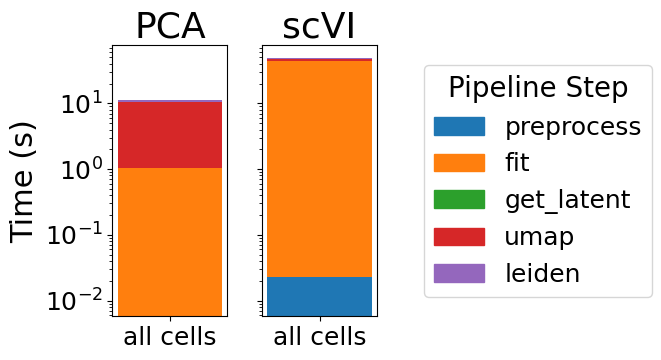

In [17]:
# Define step columns and meta
step_cols = ["preprocess", "fit", "get_latent", "umap", "leiden"]
pipeline_col = "method"

# Replace 0s with small epsilon to make log scale work
df[step_cols] = df[step_cols].replace(0, 1e-3)

# Group only by method
df_grouped = df.groupby([pipeline_col])[step_cols].mean().reset_index()

# Get unique methods and dataset sizes
pipelines = sorted(df_grouped[pipeline_col].unique())[:2]  # Only use 2 pipelines
x = np.arange(1)  # single bar per pipeline
colors = plt.cm.tab10.colors[: len(step_cols)]

# Set up 3 subplots, one per pipeline, using the third for the legend
fig, axes = plt.subplots(
    1, 3, figsize=(plotting.TEXTWIDTH_IN, 4.0), gridspec_kw={"width_ratios": [1, 1, 0.3]}, sharey=True
)

for i, pipeline in enumerate(pipelines):
    ax = axes[i]
    data = df_grouped[df_grouped[pipeline_col] == pipeline]
    bottoms = np.zeros(1)

    for j, step in enumerate(step_cols):
        step_val = data[step].values[0] if len(data) else 1e-3
        ax.bar(x, [step_val], bottom=bottoms, label=step, color=colors[j])
        bottoms += step_val

    ax.set_xticks(x)
    ax.set_xticklabels(["all cells"])
    ax.set_title("PCA" if pipeline == "pca" else "scVI")
    ax.set_yscale("log")
    if i == 0:
        ax.set_ylabel("Time (s)")

# Remove third axis and use it for the legend
axes[2].axis("off")
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(step_cols))
]
axes[2].legend(
    legend_handles,
    step_cols,
    title="Pipeline Step",
    loc="center left",
    # fontsize="medium",
)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "pipeline_timing.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
del df
del df_grouped

### Losses 

In [19]:
scvi_results = dropout_results[dropout_results["method"] == "scvi"].copy()
losses = scvi_results.losses.apply(parse_params).apply(pd.Series)
scvi_results = pd.concat([scvi_results.drop(columns=['losses', 'leiden', 'umap', 'timings', 'additional']), losses], axis=1)
scvi_results["dropout"] = pd.to_numeric(scvi_results["dropout"], errors="coerce")

# pull training history into a column
def get_history(additional):
    if isinstance(additional, dict):
        return additional.get("training_history")
    return None
scvi_results["training_history"] = dropout_results.loc[scvi_results.index, "additional"].apply(get_history)

scvi_results.head().astype(str)

,method,genes,cells,dropout,factor,rate,datatype,dataname,seed,parameters,reconstruction_loss,kl_loss,elbo,training_history
0,scvi,2000,None,0.9388,None,0.6,TS,Ear,13,"{'n_latent': 20, 'n_hidden': 128, 'n_layers': ...",-523.8316650390625,1083.3015747070312,559.4699096679688,{'kl_weight': kl_weight\nepoch ...
2,scvi,2000,None,0.9817,None,1.0,TS,Ear,13,"{'n_latent': 10, 'n_hidden': 128, 'n_layers': ...",-218.37342834472656,455.45204162597656,237.07861328125,{'kl_weight': kl_weight\nepoch ...
3,scvi,2000,None,0.8962,None,0.2,TS,Ear,13,"{'n_latent': 20, 'n_hidden': 128, 'n_layers': ...",-720.5885620117188,1478.2984619140625,757.7098999023438,{'kl_weight': kl_weight\nepoch ...
9,scvi,2000,None,0.9177,None,0.4,TS,Ear,13,"{'n_latent': 10, 'n_hidden': 128, 'n_layers': ...",-648.6873779296875,1319.957275390625,671.2698974609375,{'kl_weight': kl_weight\nepoch ...
10,scvi,2000,None,0.9177,None,0.4,TS,Ear,13,"{'n_latent': 20, 'n_hidden': 128, 'n_layers': ...",-632.5758666992188,1301.087158203125,668.5112915039062,{'kl_weight': kl_weight\nepoch ...


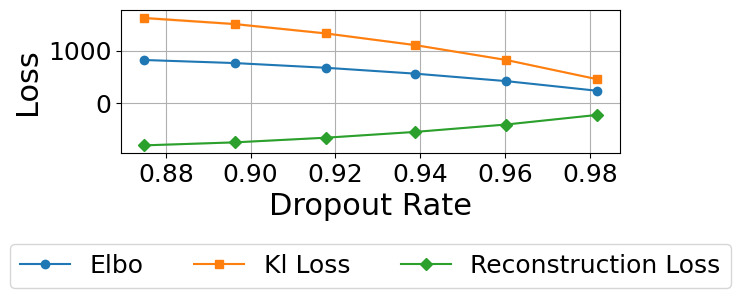

In [20]:
# Melt losses into long format
loss_df = scvi_results.melt(
    id_vars=["dropout", "seed"],
    value_vars=["reconstruction_loss", "kl_loss", "elbo"],
    var_name="loss_type",
    value_name="loss_value",
)

# Compute mean and std over seeds
summary = (
    loss_df.groupby(["dropout", "loss_type"])
    .agg(mean=("loss_value", "mean"), std=("loss_value", "std"))
    .reset_index()
)

# Unique categories
loss_types = sorted(summary["loss_type"].unique())

# Assign markers for loss types
marker_cycle = itertools.cycle(["o", "s", "D", "^", "v", "P", "X", "*", "h", "8"])
loss_markers = {loss: next(marker_cycle) for loss in loss_types}

fig, ax = plt.subplots(figsize=(1.1*plotting.TEXTWIDTH_IN, 4.5))

for loss_type in loss_types:
    data = summary[summary["loss_type"] == loss_type].sort_values("dropout")

    ax.plot(
        data["dropout"],
        data["mean"],
        marker=loss_markers[loss_type],
        markersize=6,
        label=loss_type.replace("_", " ").title(),
    )

    ax.fill_between(
        data["dropout"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2,
    )

ax.set_xlabel("Dropout Rate")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.55), ncol=len(loss_types), frameon=True)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "loss_vs_dropout.png", dpi=300, bbox_inches="tight")
plt.show()

### scVI loss vs epoch

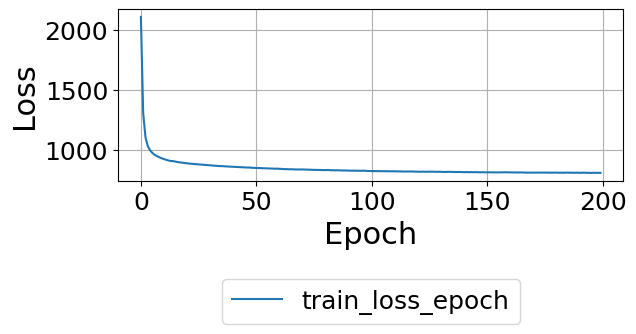

In [21]:
# Pick one run to inspect
target = float(TARGET) # dropout we want to inspect

matches = scvi_results.loc[
    np.isclose(scvi_results["dropout"], target)
]

if matches.empty:
    print("No close match found for target:", target)
    print("Available dropout values:")
    print(sorted(scvi_results["dropout"].unique()))
else:
    row = matches.iloc[0]

# Get training history
hist = row["training_history"]

# Build loss-vs-epoch DataFrame from dict of DataFrames
def to_series(d):
    if "value" in d.columns:
        return d["value"].reset_index(drop=True)
    return d.iloc[:, 0].reset_index(drop=True)

df = pd.DataFrame({k: to_series(v) for k, v in hist.items()})

plt.figure(figsize=(plotting.TEXTWIDTH_IN, 4.7))
for col in ["train_loss_epoch"]:
    plt.plot(df.index, df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.5), frameon=True)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / f"scvi_training_loss_dropout_{target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [22]:
del df
del scvi_results
del summary
del loss_df
del hist
del row